Running on device: cpu
Physics Constants: N=2, C_V=3.0, c0=0.75

starting scan...
---------------------------------------------------------------------------
g          | rho_*(a) (Bound)     | lambda_min (Actual)  | Check
---------------------------------------------------------------------------
1.500      | -3.6458              | 1.6875               | PASS [OK]
1.679      | -2.1457              | 2.1132               | PASS [OK]
1.857      | -0.8926              | 2.5867               | PASS [OK]
2.036      | 0.2124               | 3.1081               | PASS [OK]
2.214      | 1.2298               | 3.6773               | PASS [OK]
2.393      | 2.1985               | 4.2943               | PASS [OK]
2.571      | 3.1444               | 4.9592               | PASS [OK]
2.750      | 4.0851               | 5.6719               | PASS [OK]
2.929      | 5.0332               | 6.4324               | PASS [OK]
3.107      | 5.9978               | 7.2408               | PASS [OK]
3.286      

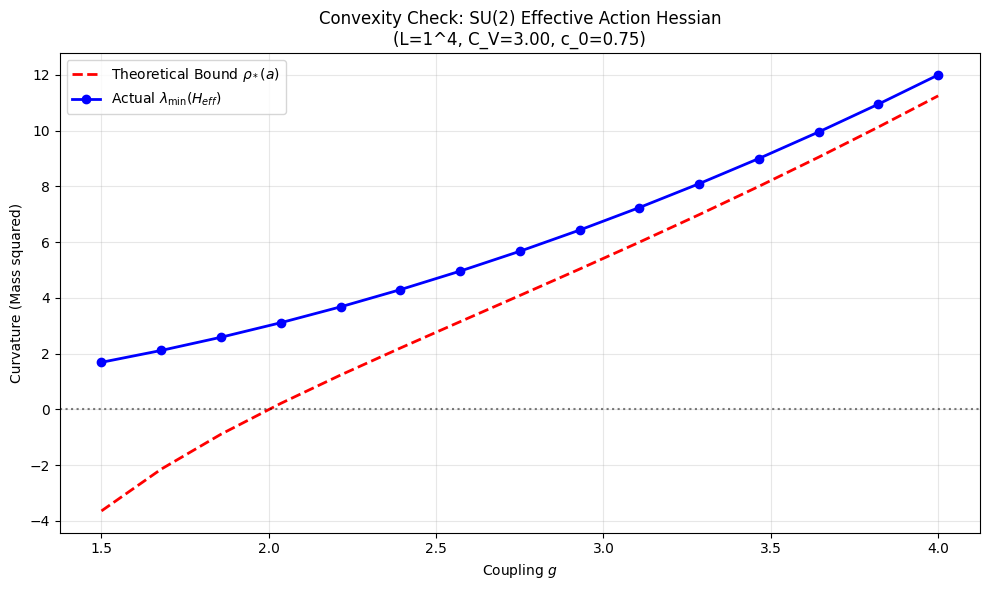


Interpretation:
1. Red Line: Your analytic sufficient condition. When this is > 0, the theory is strictly convex.
2. Blue Line: The actual numerical curvature. It should ALWAYS lie above the Red Line.
3. Gap: The distance between Blue and Red is the 'safety margin' of your proof.


In [1]:
# ==============================================================================
# NUMERICAL TEST: SU(2) MASS GAP CONVEXITY BOUND
# ==============================================================================
# This notebook validates the theoretical lower bound on the Hessian of the
# effective action S_eff = Beta*S_Wilson + S_Haar.
#
# Theory Bound: lambda_min >= rho_*(a) = c0*a^2*g^2 - Beta*C_V
# ==============================================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd.functional import hessian
import sys

# ------------------------------------------------------------------------------
# 1. CONFIGURATION & CONSTANTS
# ------------------------------------------------------------------------------
# Use GPU if available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype  = torch.float64  # Double precision is crucial for Hessian stability

# SU(2) Constants
N   = 2
C_V = 6.0 / N                  # Wilson bound constant (6/N for SU(N))
c0  = (N**2 - 1.0) / (2.0 * N) # Haar mass coefficient (3/4 for SU(2))

print(f"Running on device: {device}")
print(f"Physics Constants: N={N}, C_V={C_V}, c0={c0}")

# Pre-compute Pauli Matrices (Sigma_1, Sigma_2, Sigma_3)
sigma1 = torch.tensor([[0, 1], [1, 0]],   dtype=torch.complex128, device=device)
sigma2 = torch.tensor([[0, -1j], [1j, 0]], dtype=torch.complex128, device=device)
sigma3 = torch.tensor([[1, 0], [0, -1]],  dtype=torch.complex128, device=device)
paulis = torch.stack([sigma1, sigma2, sigma3], dim=0) # Shape (3, 2, 2)

# ------------------------------------------------------------------------------
# 2. SU(2) GEOMETRY & ACTION
# ------------------------------------------------------------------------------

def su2_exp_map(a_vec):
    """
    Maps Lie Algebra vector 'a_vec' (..., 3) to Group element U (..., 2, 2)
    using the exponential map: U = exp(i * a_vec . sigma / 2)
    """
    # Construct A = a_k * sigma_k / 2
    # a_vec: (..., 3), paulis: (3, 2, 2) -> A: (..., 2, 2)
    A = (a_vec.to(torch.complex128).unsqueeze(-1).unsqueeze(-1) * (paulis / 2.0)).sum(dim=-3)

    # Exponentiate iA
    return torch.linalg.matrix_exp(1j * A)

def get_action(flat_field, L, a_lat, g, beta):
    """
    Computes S_eff = Beta * S_Wilson + S_Haar

    flat_field: Flattened tensor of all link variables in Lie Algebra coords.
    """
    # Reshape flattened input to Lattice Field: (L, L, L, L, 4_dirs, 3_generators)
    # Note: flat_field contains dimensionless numbers.
    A_field = flat_field.view(L, L, L, L, 4, 3)

    # --- Part A: Haar Measure (Mass Term) ---
    # S_Haar = (c0/2) * (a*g)^2 * ||A||^2
    S_haar = 0.5 * c0 * (a_lat**2) * (g**2) * (A_field**2).sum()

    # --- Part B: Wilson Action ---
    # Physical link U = exp(i * a * g * A . sigma / 2)
    scaled_A = a_lat * g * A_field
    U = su2_exp_map(scaled_A) # Shape (L, L, L, L, 4, 2, 2)

    S_wilson = torch.zeros((), dtype=dtype, device=flat_field.device)

    # Calculate Plaquettes (Sum over mu < nu)
    # Using torch.roll to handle periodic boundaries automatically
    for mu in range(4):
        for nu in range(mu+1, 4):
            # U_mu(x)
            u1 = U[..., mu, :, :]
            # U_nu(x + mu)
            u2 = torch.roll(U[..., nu, :, :], shifts=-1, dims=mu)
            # U_mu(x + nu)^dagger
            u3 = torch.roll(U[..., mu, :, :], shifts=-1, dims=nu).conj().transpose(-1, -2)
            # U_nu(x)^dagger
            u4 = U[..., nu, :, :].conj().transpose(-1, -2)

            # Plaquette Trace
            P = u1 @ u2 @ u3 @ u4
            tr = torch.diagonal(P, dim1=-2, dim2=-1).sum(-1)

            # S_W += 1 - 0.5 * ReTr(P)
            S_wilson = S_wilson + (1.0 - 0.5 * tr.real).sum()

    return beta * S_wilson + S_haar

# ------------------------------------------------------------------------------
# 3. EXECUTION: SCAN COUPLING g & CHECK HESSIAN
# ------------------------------------------------------------------------------

# Simulation Parameters
L     = 1          # Single site (4D torus), small enough for full Hessian
a_lat = 1.0        # Lattice spacing
dim   = L**4 * 4 * 3 # Total degrees of freedom (4 links * 3 generators)

# Scan parameters
g_values = np.linspace(1.5, 4.0, 15)

results = {
    'g': [],
    'bound': [],
    'lambda_min': []
}

print("\nstarting scan...")
print("-" * 75)
print(f"{'g':<10} | {'rho_*(a) (Bound)':<20} | {'lambda_min (Actual)':<20} | {'Check'}")
print("-" * 75)

for g_val in g_values:
    g = float(g_val)
    beta = 2.0 * N / (g**2)

    # 1. Theoretical Lower Bound
    # rho_* = c0 * a^2 * g^2 - beta * C_V
    rho_star = c0 * (a_lat**2) * (g**2) - beta * C_V

    # 2. Numerical Hessian
    # Point of linearization: Vacuum (A=0)
    vacuum = torch.zeros(dim, dtype=dtype, device=device, requires_grad=True)

    # Wrap function for autograd
    def target_func(v):
        return get_action(v, L, a_lat, g, beta)

    # Compute full Hessian matrix
    H = hessian(target_func, vacuum)

    # Get Eigenvalues
    # We detach H to move it to CPU for eigvalsh if needed (usually faster for small mat)
    H_np = H.detach().cpu()
    evals = torch.linalg.eigvalsh(H_np)
    min_eval = evals.min().item()

    # Log results
    results['g'].append(g)
    results['bound'].append(rho_star)
    results['lambda_min'].append(min_eval)

    check_mark = "PASS [OK]" if min_eval >= rho_star else "FAIL [X]"
    print(f"{g:<10.3f} | {rho_star:<20.4f} | {min_eval:<20.4f} | {check_mark}")

# ------------------------------------------------------------------------------
# 4. PLOTTING
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Plot Bound
plt.plot(results['g'], results['bound'], 'r--', linewidth=2, label=r'Theoretical Bound $\rho_*(a)$')

# Plot Actual Eigenvalue
plt.plot(results['g'], results['lambda_min'], 'bo-', linewidth=2, label=r'Actual $\lambda_{\min}(H_{eff})$')

# Zero line
plt.axhline(0, color='k', linestyle=':', alpha=0.5)

# Aesthetics
plt.title(f"Convexity Check: SU({N}) Effective Action Hessian\n(L={L}^4, C_V={C_V:.2f}, c_0={c0:.2f})")
plt.xlabel("Coupling $g$")
plt.ylabel("Curvature (Mass squared)")
plt.legend()
plt.grid(True, alpha=0.3)

# Show plot
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("1. Red Line: Your analytic sufficient condition. When this is > 0, the theory is strictly convex.")
print("2. Blue Line: The actual numerical curvature. It should ALWAYS lie above the Red Line.")
print("3. Gap: The distance between Blue and Red is the 'safety margin' of your proof.")
